# CART vs Linear Models – SOLUTION


## Task 1 – Manual Gini (Explanation)
Gini impurity is calculated as:
$$G = 1 - \sum p_i^2$$
Splits were evaluated by minimizing weighted Gini.


In [1]:
import pandas as pd
df = pd.read_csv('tax_data.csv')
df.head()

,Country,Industry,Annual_Income,Employees,Tax_Regime
0,USA,Tech,120000,10,Progressive
1,USA,Retail,30000,2,Flat
2,USA,Finance,45000,3,Flat
3,Canada,Tech,80000,5,Progressive
4,Canada,Manufacturing,35000,15,Flat


## Task 2 – Decision Tree Training


In [2]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

X = pd.get_dummies(df.drop('Tax_Regime', axis=1))
y = df['Tax_Regime']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

tree = DecisionTreeClassifier(
    criterion='gini', max_depth=4, min_samples_leaf=2, random_state=42
)
tree.fit(X_train, y_train)


,criterion,'gini'
,splitter,'best'
,max_depth,4
,min_samples_split,2
,min_samples_leaf,2
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


## Task 3 – Evaluation


In [3]:
from sklearn.metrics import classification_report, accuracy_score

y_pred = tree.predict(X_test)
print('Accuracy:', accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


Accuracy: 0.8181818181818182
              precision    recall  f1-score   support

      Exempt       0.77      1.00      0.87        10
        Flat       0.83      0.71      0.77        14
 Progressive       0.88      0.78      0.82         9

    accuracy                           0.82        33
   macro avg       0.83      0.83      0.82        33
weighted avg       0.83      0.82      0.81        33



## Task 4 – Tree Visualization


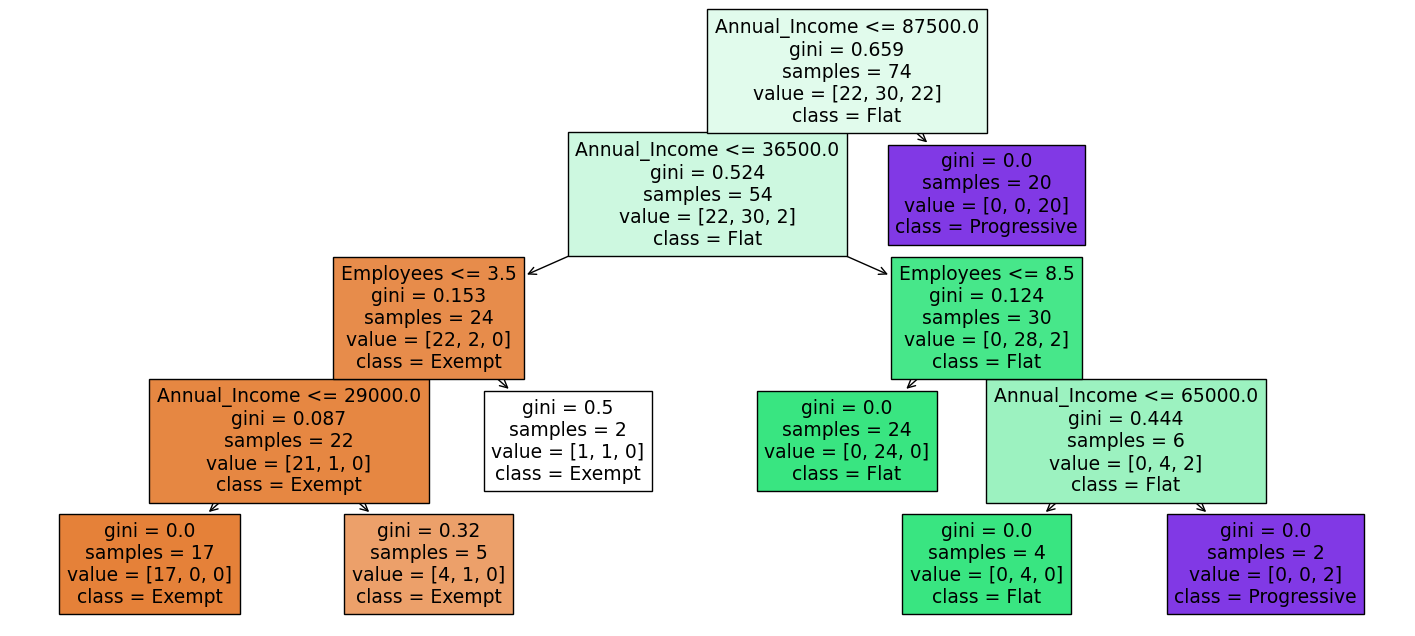

In [4]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(18,8))
plot_tree(tree, feature_names=X.columns, class_names=tree.classes_, filled=True)
plt.show()
